# E-commerce Sales Analysis - Business Performance Review

This notebook analyzes order, product, customer and review data to answer a
set of recurring business questions about sales performance. It is built to
be re-run for any year, any single month, and any comparison period by
changing the values in the Configuration section - no other code needs to
change.


## Table of Contents

1. Introduction & Business Objectives
2. Data Loading & Configuration
3. Data Dictionary
4. Data Preparation & Transformation
5. Business Metrics Calculation
    - 5.1 Revenue Performance
    - 5.2 Product Category Performance
    - 5.3 Geographic Performance
    - 5.4 Customer Experience: Satisfaction & Delivery
6. Summary of Observations


## 1. Introduction & Business Objectives

This analysis answers the following business questions for a configurable
analysis period:

- How much revenue was generated, and how does it compare to a prior period?
- What is the month-over-month revenue trend within the analysis period?
- Which product categories and which states drive the most revenue?
- How satisfied are customers with their orders, and how does delivery speed
  relate to review scores?

The underlying logic lives in two reusable modules kept alongside this
notebook:

- `data_loader.py` - loading, filtering, joining and cleaning the raw data.
- `business_metrics.py` - computing the metrics and metric tables above from
  an already prepared dataset.

Keeping data preparation and metric calculation in separate, tested modules
means the same functions can be reused in another notebook, a script, or a
dashboard without copying logic.


## 2. Data Loading & Configuration

This section imports the libraries and local modules used throughout the
notebook, defines a consistent chart style, sets the analysis configuration,
and loads the raw data.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px

import data_loader as dl
import business_metrics as bm


### Chart Style

A single, consistent color palette is used for every chart in this notebook:
one color for the analysis period, one for the comparison period, and one
light-to-dark sequential ramp for magnitude (the choropleth and the review
score distribution, which is an ordered 1-5 scale). Colors are assigned by
role rather than chosen per chart, so every chart in the notebook reads as
part of the same report.


In [2]:
# Chart colors, assigned by role and reused across every chart below.
PRIMARY_COLOR = "#2a78d6"        # analysis period
COMPARISON_COLOR = "#eb6834"     # comparison period
SEQUENTIAL_SCALE = [             # light -> dark, for continuous magnitude (choropleth)
    "#fcfcfb", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#1c5cab", "#0d366b",
]
ORDINAL_SCALE = [                # light -> dark, for the 5-point review score scale
    "#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281",
]

sns.set_theme(
    style="whitegrid",
    rc={
        "axes.edgecolor": "#c3c2b7",
        "axes.labelcolor": "#0b0b0b",
        "text.color": "#0b0b0b",
        "xtick.color": "#52514e",
        "ytick.color": "#52514e",
        "grid.color": "#e1e0d9",
        "figure.facecolor": "#fcfcfb",
        "axes.facecolor": "#fcfcfb",
    },
)


### Analysis Configuration

Change these values to re-run the analysis for a different year, a single
month, or a different comparison period. `ANALYSIS_MONTH` and
`COMPARISON_MONTH` can be set to `None` to analyze a full year.


In [3]:
DATA_PATH = "../ecommerce_data"
ANALYSIS_YEAR = 2023
ANALYSIS_MONTH = None       # 1-12, or None for the full year
COMPARISON_YEAR = 2022
COMPARISON_MONTH = None     # 1-12, or None for the full year
ORDER_STATUS = "delivered"  # order status considered a completed sale


def format_period(year, month):
    return f"{year}-{month:02d}" if month else f"{year}"


ANALYSIS_PERIOD_LABEL = format_period(ANALYSIS_YEAR, ANALYSIS_MONTH)
COMPARISON_PERIOD_LABEL = format_period(COMPARISON_YEAR, COMPARISON_MONTH) if COMPARISON_YEAR else None

print(f"Analysis period: {ANALYSIS_PERIOD_LABEL}")
print(f"Comparison period: {COMPARISON_PERIOD_LABEL}")
print(f"Order status filter: {ORDER_STATUS}")


Analysis period: 2023
Comparison period: 2022
Order status filter: delivered


### Load Raw Data


In [4]:
raw = dl.load_raw_data(DATA_PATH)

for name, df in raw.items():
    print(f"{name}: {len(df):,} rows, {df.shape[1]} columns")


orders: 10,000 rows, 8 columns
order_items: 16,047 rows, 7 columns
products: 6,000 rows, 9 columns
customers: 8,000 rows, 5 columns
reviews: 6,571 rows, 7 columns


## 3. Data Dictionary

Key columns used in this analysis, and the business terms built from them.

| Dataset | Column | Description |
|---|---|---|
| orders | order_id | Unique identifier for an order |
| orders | order_status | Lifecycle status of the order: delivered, shipped, canceled, processing, pending, or returned |
| orders | order_purchase_timestamp | When the customer placed the order |
| orders | order_delivered_customer_date | When the order was delivered to the customer; missing if not yet delivered |
| order_items | order_id | Order the line item belongs to |
| order_items | product_id | Product sold in this line item |
| order_items | price | Price of this line item, in USD |
| products | product_id | Unique identifier for a product |
| products | product_category_name | Product category |
| customers | customer_id | Identifier for the customer record attached to an order |
| customers | customer_state | US state of the customer |
| reviews | order_id | Order the review refers to |
| reviews | review_score | Customer rating from 1 (lowest) to 5 (highest) |

Business terms used throughout this notebook:

- **Revenue**: sum of `price` across order line items for orders with status
  `delivered` (the value of `ORDER_STATUS`).
- **Order**: a unique `order_id`. An order can contain multiple line items.
- **Average order value (AOV)**: total revenue divided by the number of
  unique orders.
- **Delivery speed**: number of days between `order_purchase_timestamp` and
  `order_delivered_customer_date`.
- **Delivery time bucket**: delivery speed grouped into labeled ranges (see
  `data_loader.categorize_delivery_speed`) for comparing review scores across
  delivery speeds.


## 4. Data Preparation & Transformation

Build an item-level sales dataset from orders and order items, then filter it
to the analysis and comparison periods defined above.


In [5]:
sales_all = dl.build_sales_dataset(raw["orders"], raw["order_items"])

analysis_sales = dl.filter_by_status(
    dl.filter_by_period(
        sales_all, "order_purchase_timestamp", year=ANALYSIS_YEAR, month=ANALYSIS_MONTH
    ),
    status=ORDER_STATUS,
)

comparison_sales = None
if COMPARISON_YEAR:
    comparison_sales = dl.filter_by_status(
        dl.filter_by_period(
            sales_all, "order_purchase_timestamp", year=COMPARISON_YEAR, month=COMPARISON_MONTH
        ),
        status=ORDER_STATUS,
    )

print(f"Analysis period line items: {len(analysis_sales):,}")
if comparison_sales is not None:
    print(f"Comparison period line items: {len(comparison_sales):,}")


Analysis period line items: 7,448
Comparison period line items: 7,641


Enrich the analysis period's sales data with product category, customer
state, delivery speed and review score, for use in the sections below.


In [6]:
analysis_sales_enriched = dl.merge_product_category(analysis_sales, raw["products"])
analysis_sales_enriched = dl.merge_customer_state(analysis_sales_enriched, raw["customers"])
analysis_sales_enriched = dl.add_delivery_speed(analysis_sales_enriched)
analysis_sales_enriched = dl.merge_review_scores(analysis_sales_enriched, raw["reviews"])
analysis_sales_enriched["delivery_time_bucket"] = analysis_sales_enriched["delivery_speed_days"].apply(
    dl.categorize_delivery_speed
)

analysis_sales_enriched.head()


,order_id,order_item_id,product_id,price,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,product_category_name,customer_state,delivery_speed_days,review_score,delivery_time_bucket
0,ord_5fa044951857e02fd1347b47,1,prod_9b6f1793388ae983f852d189,111.91,cust_2d36e4b647be13c15df550af,delivered,2023-04-24 13:05:32.579655,2023-05-01 02:05:32.579655,grocery_gourmet_food,TN,6,5,4-7 days
1,ord_5fa044951857e02fd1347b47,2,prod_c7b5997a4d0061a9f50e874c,878.42,cust_2d36e4b647be13c15df550af,delivered,2023-04-24 13:05:32.579655,2023-05-01 02:05:32.579655,electronics,TN,6,5,4-7 days
2,ord_43b53981d951f855231d09ec,1,prod_496e129d773e9587e8ddc065,749.83,cust_e670ce607e4f6aa14935ece0,delivered,2023-12-10 05:13:58.249202,2023-12-19 09:13:58.249202,sports_outdoors,FL,9,5,8+ days
3,ord_e60b1e267fd32d93c4d0745b,1,prod_139fc7c40b163ec81342741e,361.54,cust_deec5ec61bd39869531896b3,delivered,2023-04-11 05:42:57.214593,2023-04-22 20:42:57.214593,home_garden,PA,11,5,8+ days
4,ord_e60b1e267fd32d93c4d0745b,2,prod_8668b3ebccd7183bae97138a,25.59,cust_deec5ec61bd39869531896b3,delivered,2023-04-11 05:42:57.214593,2023-04-22 20:42:57.214593,grocery_gourmet_food,PA,11,5,8+ days


## 5. Business Metrics Calculation

Each subsection below computes one group of metrics using
`business_metrics.py` and visualizes the result.


### 5.1 Revenue Performance

Total revenue, order count and average order value for the analysis period,
compared to the comparison period, plus the month-over-month revenue trend
within the analysis period.


In [7]:
revenue = bm.revenue_summary(analysis_sales, comparison_sales)

print(f"Revenue summary for {ANALYSIS_PERIOD_LABEL}")
print(f"Total revenue: ${revenue['total_revenue']:,.2f}")
print(f"Total orders: {revenue['total_orders']:,}")
print(f"Total line items: {revenue['total_items']:,}")
print(f"Average order value: ${revenue['avg_order_value']:,.2f}")

if "revenue_change_pct" in revenue:
    print(f"\nCompared to {COMPARISON_PERIOD_LABEL}:")
    print(f"Revenue change: {revenue['revenue_change_pct']:+.2f}%")
    print(f"Order count change: {revenue['order_count_change_pct']:+.2f}%")
    print(f"Average order value change: {revenue['avg_order_value_change_pct']:+.2f}%")


Revenue summary for 2023
Total revenue: $3,360,294.74
Total orders: 4,635
Total line items: 7,448
Average order value: $724.98

Compared to 2022:
Revenue change: -2.46%
Order count change: -2.40%
Average order value change: -0.06%


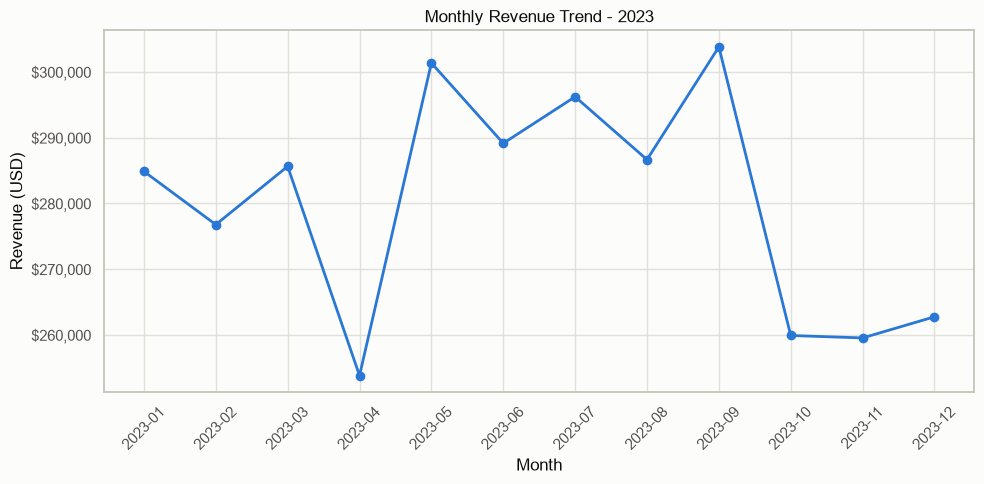

,period,revenue,revenue_change_pct
0,2023-01,284855.48,NaN
1,2023-02,276758.54,-2.842473
2,2023-03,285618.77,3.201430
3,2023-04,253794.62,-11.142177
4,2023-05,301347.96,18.736938
5,2023-06,289126.72,-4.055524
6,2023-07,296209.39,2.449677
7,2023-08,286645.60,-3.228726
8,2023-09,303793.15,5.982143
9,2023-10,259890.15,-14.451610


In [8]:
monthly_trend = bm.monthly_revenue_trend(analysis_sales)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    monthly_trend["period"], monthly_trend["revenue"],
    marker="o", color=PRIMARY_COLOR, linewidth=2,
)
ax.set_title(f"Monthly Revenue Trend - {ANALYSIS_PERIOD_LABEL}")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly_trend


### 5.2 Product Category Performance

Revenue by product category for the analysis period, ranked highest to
lowest.


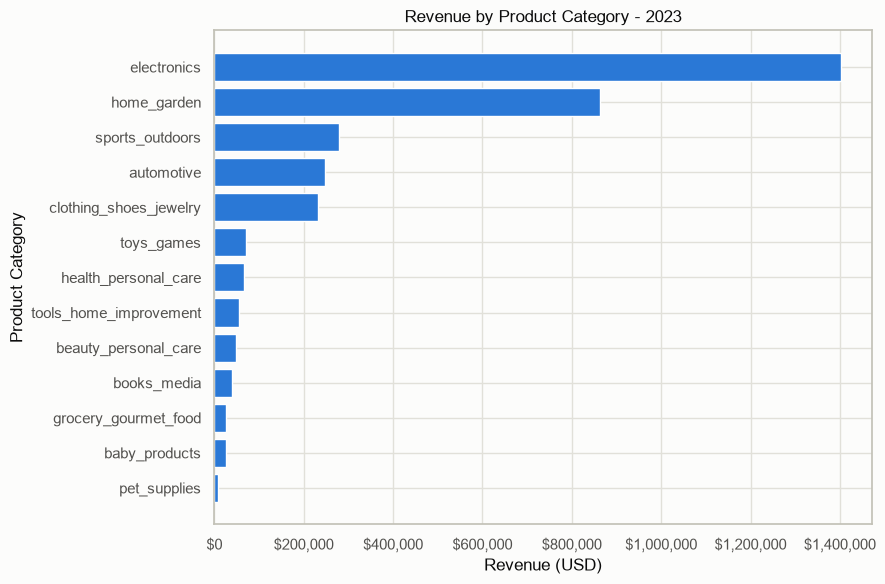

,product_category_name,revenue,revenue_share_pct
0,electronics,1401359.21,41.703461
1,home_garden,862653.27,25.671953
2,sports_outdoors,278845.32,8.298240
3,automotive,247707.10,7.371588
4,clothing_shoes_jewelry,232745.04,6.926328
5,toys_games,70163.64,2.088020
6,health_personal_care,65370.27,1.945373
7,tools_home_improvement,54280.33,1.615344
8,beauty_personal_care,49213.30,1.464553
9,books_media,38559.08,1.147491


In [9]:
sales_by_category = bm.product_category_performance(
    dl.merge_product_category(analysis_sales, raw["products"])
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(sales_by_category["product_category_name"], sales_by_category["revenue"], color=PRIMARY_COLOR)
ax.invert_yaxis()
ax.set_title(f"Revenue by Product Category - {ANALYSIS_PERIOD_LABEL}")
ax.set_xlabel("Revenue (USD)")
ax.set_ylabel("Product Category")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

sales_by_category


### 5.3 Geographic Performance

Revenue by customer state for the analysis period.


In [10]:
sales_by_state = bm.geographic_performance(
    dl.merge_customer_state(analysis_sales, raw["customers"])
)

fig = px.choropleth(
    sales_by_state,
    locations="customer_state",
    color="revenue",
    locationmode="USA-states",
    scope="usa",
    title=f"Revenue by State - {ANALYSIS_PERIOD_LABEL}",
    color_continuous_scale=SEQUENTIAL_SCALE,
    labels={"revenue": "Revenue (USD)"},
)
fig.show()

sales_by_state.head(10)


,customer_state,revenue,revenue_share_pct
0,CA,537880.74,16.006951
1,TX,403303.49,12.002027
2,FL,310195.84,9.231209
3,NY,253111.85,7.532430
4,IL,185930.89,5.533172
5,PA,173260.68,5.156116
6,OH,157619.72,4.690652
7,GA,146414.65,4.357197
8,MI,132325.60,3.937916
9,NC,128314.74,3.818556


### 5.4 Customer Experience: Satisfaction & Delivery

Review score distribution, delivery speed, and how review scores vary with
delivery speed, for the analysis period.


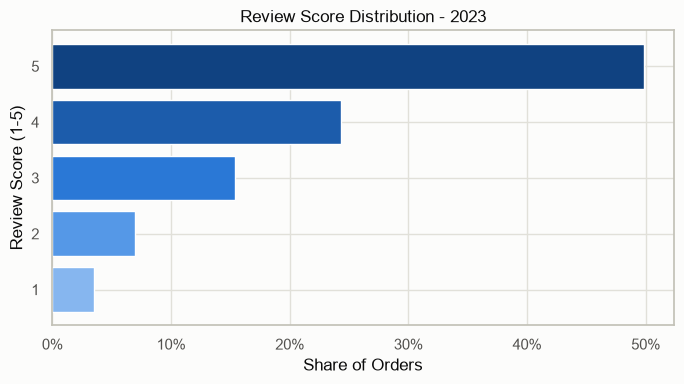

Average review score: 4.10 out of 5


review_score
1    0.034729
2    0.069457
3    0.153798
4    0.243101
5    0.498915
Name: proportion, dtype: float64

In [11]:
sales_with_reviews = dl.merge_review_scores(analysis_sales, raw["reviews"])
review_distribution = bm.review_score_distribution(sales_with_reviews)
avg_review_score = (review_distribution.index.to_series() * review_distribution.values).sum()

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(
    review_distribution.index.astype(str), review_distribution.values,
    color=ORDINAL_SCALE,
)
ax.set_title(f"Review Score Distribution - {ANALYSIS_PERIOD_LABEL}")
ax.set_xlabel("Share of Orders")
ax.set_ylabel("Review Score (1-5)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

print(f"Average review score: {avg_review_score:.2f} out of 5")
review_distribution


In [12]:
sales_with_delivery = dl.add_delivery_speed(analysis_sales)
sales_with_delivery_and_reviews = dl.merge_review_scores(sales_with_delivery, raw["reviews"])
sales_with_delivery_and_reviews["delivery_time_bucket"] = sales_with_delivery_and_reviews[
    "delivery_speed_days"
].apply(dl.categorize_delivery_speed)

delivery = bm.delivery_performance(sales_with_delivery_and_reviews)
review_by_delivery_bucket = bm.review_score_by_delivery_bucket(sales_with_delivery_and_reviews)

print(f"Average delivery time: {delivery['avg_delivery_days']:.1f} days")
print(f"Median delivery time: {delivery['median_delivery_days']:.1f} days")


Average delivery time: 8.0 days
Median delivery time: 8.0 days


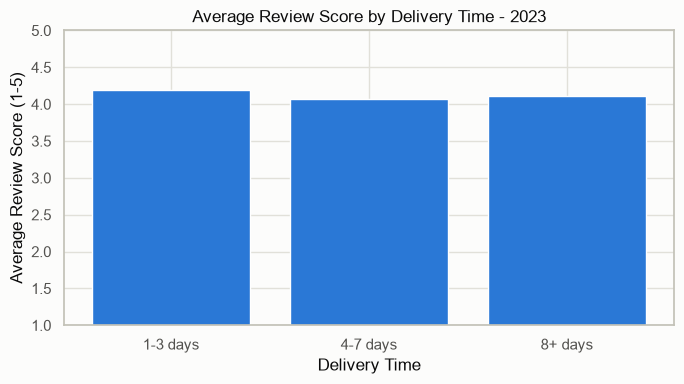

,delivery_time_bucket,avg_review_score,order_count
0,1-3 days,4.193966,232
1,4-7 days,4.075063,1199
2,8+ days,4.108138,1794


In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    review_by_delivery_bucket["delivery_time_bucket"],
    review_by_delivery_bucket["avg_review_score"],
    color=PRIMARY_COLOR,
)
ax.set_title(f"Average Review Score by Delivery Time - {ANALYSIS_PERIOD_LABEL}")
ax.set_xlabel("Delivery Time")
ax.set_ylabel("Average Review Score (1-5)")
ax.set_ylim(1, 5)
plt.tight_layout()
plt.show()

review_by_delivery_bucket


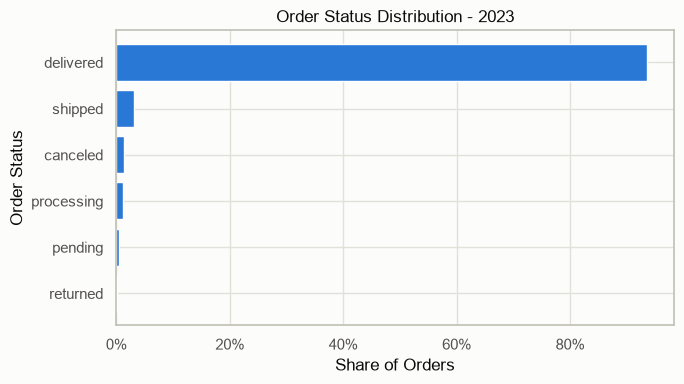

order_status
delivered     0.936364
shipped       0.031919
canceled      0.012929
processing    0.011919
pending       0.005051
returned      0.001818
Name: proportion, dtype: float64

In [14]:
orders_with_dates = raw["orders"].assign(
    order_purchase_timestamp=pd.to_datetime(raw["orders"]["order_purchase_timestamp"])
)
orders_in_period = dl.filter_by_period(
    orders_with_dates, "order_purchase_timestamp", year=ANALYSIS_YEAR, month=ANALYSIS_MONTH
)
status_distribution = bm.order_status_distribution(orders_in_period)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(status_distribution.index, status_distribution.values, color=PRIMARY_COLOR)
ax.invert_yaxis()
ax.set_title(f"Order Status Distribution - {ANALYSIS_PERIOD_LABEL}")
ax.set_xlabel("Share of Orders")
ax.set_ylabel("Order Status")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

status_distribution


## 6. Summary of Observations

The observations below are generated directly from the metrics computed
above, so they stay accurate when the configuration in Section 2 changes.


In [15]:
top_category = sales_by_category.iloc[0]
top_state = sales_by_state.iloc[0]
fastest_bucket = review_by_delivery_bucket.iloc[0]
slowest_bucket = review_by_delivery_bucket.iloc[-1]

print(f"SUMMARY OF OBSERVATIONS - {ANALYSIS_PERIOD_LABEL}")
print("-" * 60)
print(
    f"Total revenue was ${revenue['total_revenue']:,.2f} across "
    f"{revenue['total_orders']:,} orders (average order value "
    f"${revenue['avg_order_value']:,.2f})."
)
if "revenue_change_pct" in revenue:
    print(
        f"Compared to {COMPARISON_PERIOD_LABEL}, revenue changed by "
        f"{revenue['revenue_change_pct']:+.2f}%, order count by "
        f"{revenue['order_count_change_pct']:+.2f}%, and average order "
        f"value by {revenue['avg_order_value_change_pct']:+.2f}%."
    )
print(
    f"The leading product category was '{top_category['product_category_name']}' "
    f"with ${top_category['revenue']:,.2f} "
    f"({top_category['revenue_share_pct']:.1f}% of revenue)."
)
print(
    f"The leading state by revenue was {top_state['customer_state']} with "
    f"${top_state['revenue']:,.2f} ({top_state['revenue_share_pct']:.1f}% of revenue)."
)
print(f"Average review score was {avg_review_score:.2f} out of 5.")
print(
    f"Average delivery time was {delivery['avg_delivery_days']:.1f} days "
    f"(median {delivery['median_delivery_days']:.1f} days)."
)
print(
    f"Orders delivered in {fastest_bucket['delivery_time_bucket']} had an "
    f"average review score of {fastest_bucket['avg_review_score']:.2f}; "
    f"orders delivered in {slowest_bucket['delivery_time_bucket']} had an "
    f"average review score of {slowest_bucket['avg_review_score']:.2f}."
)


SUMMARY OF OBSERVATIONS - 2023
------------------------------------------------------------
Total revenue was $3,360,294.74 across 4,635 orders (average order value $724.98).
Compared to 2022, revenue changed by -2.46%, order count by -2.40%, and average order value by -0.06%.
The leading product category was 'electronics' with $1,401,359.21 (41.7% of revenue).
The leading state by revenue was CA with $537,880.74 (16.0% of revenue).
Average review score was 4.10 out of 5.
Average delivery time was 8.0 days (median 8.0 days).
Orders delivered in 1-3 days had an average review score of 4.19; orders delivered in 8+ days had an average review score of 4.11.


### Reconfiguring This Analysis

To run this analysis for a different period, change the values in the
Configuration cell in Section 2 (`ANALYSIS_YEAR`, `ANALYSIS_MONTH`,
`COMPARISON_YEAR`, `COMPARISON_MONTH`, `ORDER_STATUS`) and re-run the
notebook top to bottom. No other cell needs to change.

To add a new metric, add a function to `business_metrics.py` (following the
existing docstring style) and call it from a new cell in Section 5. To
support a new raw dataset or a new join, add a loading or merge function to
`data_loader.py` in the same way.
